# Statistical forecasting with SARIMA

<div class="alert">
SARIMA is the statistical forecasting model that will help us to solve the problem that we had with ARIMA (it's flattened out into the future), by adding a new seasonal component to the ARIMA model.
</div>

In [1]:
from modules import utils
utils.configure_plotly_template(showlegend=True)


## Load data

In [2]:
path = '../../../data/statsmodels/AirPassengers_log.parquet'

In [3]:
import pandas as pd

df = pd.read_parquet(path).asfreq('ME')
df.columns = ["values"]
series = df["values"]
series.plot()

## Model fit

### ARIMA

In [ ]:
# En principio usamos ARIMA como en la lección anterior

from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(endog=series, order=(12, 1, 1))
model_fit = model.fit()
model_fit.summary()

/home/vscode/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                 values   No. Observations:                  144
Model:                ARIMA(12, 1, 1)   Log Likelihood                 247.203
Date:                Fri, 15 Aug 2025   AIC                           -466.406
Time:                        02:01:38   BIC                           -424.926
Sample:                    01-31-1949   HQIC                          -449.550
                         - 12-31-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1024      0.058      1.770      0.077      -0.011       0.216
ar.L2         -0.0646      0.055     -1.184      0.237      -0.172       0.042
ar.L3          0.0019      0.049      0.038      0.970      -0.094       0.098
ar.L4         -0.0534      0.052     -1.031      0.303      -0.155       0.048
ar.L5          0.0405      0.052      0.777      0.437      -0.062       0.143
ar.L6         -0.0260      0.046     -0.566      0.572      -0.116       0.064
ar.L7         -0.0166      0.052     -0.316      0.752      -0.119       0.086
ar.L8         -0.0874      0.052     -1.681      0.093      -0.189       0.015
ar.L9          0.0614      0.057      1.070      0.285      -0.051       0.174
ar.L10        -0.0621      0.055     -1.126      0.260      -0.170       0.046
ar.L11         0.0575      0.050      1.153      0.249      -0.040       0.155
ar.L12         0.8236      0.049     16.727      0.000       0.727       0.920
ma.L1         -0.4219      0.090     -4.684      0.000      -0.598      -0.245
sigma2         0.0016      0.000      7.497      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.13   Jarque-Bera (JB):                 2.92
Prob(Q):                              0.72   Prob(JB):                         0.23
Heteroskedasticity (H):               0.50   Skew:                             0.34
Prob(H) (two-sided):                  0.02   Kurtosis:                         3.16
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### SARIMA

In [6]:
# Ahora usamos SARIMA con el nuevo seasonal_order (to better control the seasonal patterns in the data) y tener un mejor forecast futuro

from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(endog=series, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12))
model_fit = model.fit()
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                             values   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 244.696
Date:                            Fri, 15 Aug 2025   AIC                           -483.393
Time:                                    02:05:54   BIC                           -474.767
Sample:                                01-31-1949   HQIC                          -479.888
                                     - 12-31-1960                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4017      0.073     -5.501      0.000      -0.545      -0.259
ma.S.L12      -0.5569      0.096     -5.783      0.000      -0.746      -0.368
sigma2         0.0013      0.000      9.120      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 1.90
Prob(Q):                              0.84   Prob(JB):                         0.39
Heteroskedasticity (H):               0.58   Skew:                             0.02
Prob(H) (two-sided):                  0.08   Kurtosis:                         3.59
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Forecast

<div class="alert">
We develop the forecast comparing both the ARIMA and SARIMA models.<br>
Comparing them, we see that the ARIMA model is not capturing the seasonal patterns correctly.<br>
Instead, the SARIMA model, because it knows that there is a seasonal pattern in the data, it can better capture the information.<br><br>
ARIMA is not following the upward trend, but SARIMA detects it correctly.
</div>

In [8]:
from modules import utils

df_forecast = utils.get_model_forecast(df, 'values', order=(12, 1, 1), horizon=96, historical_predictions=False)
df_forecast = utils.get_model_forecast(df_forecast, 'values', order=(0, 1, 1), seasonal_order=(0, 1, 1, 12), horizon=96, historical_predictions=False)

df_forecast.plot(color="variable")


/home/vscode/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



## Diagnostics and assumptions

In [9]:
model = SARIMAX(series, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12))
model_fit = model.fit()

In [10]:
residuals = model_fit.resid[12+1:]
residuals

1950-02-28    0.039164
1950-03-31    0.013907
                ...   
1960-11-30   -0.027164
1960-12-31   -0.014966
Freq: ME, Length: 131, dtype: float64

### Autocorrelation

#### Plot

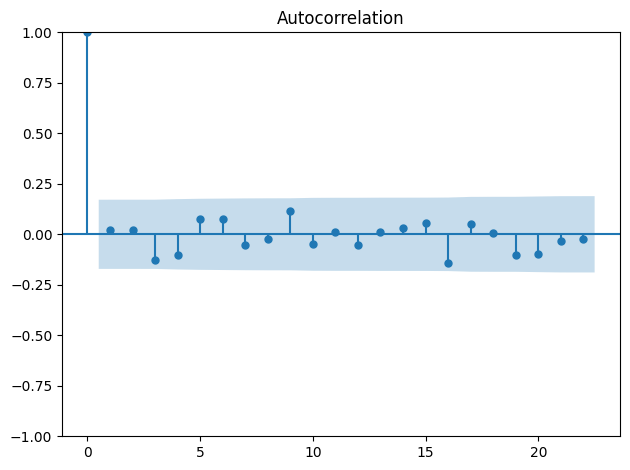

In [11]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals);

#### Test

In [12]:
from statsmodels.stats.diagnostic import acorr_ljungbox

acorr_ljungbox(residuals, lags=[10, 20, 30]).style

,lb_stat,lb_pvalue
10,8.040576,0.624873
20,15.690971,0.735601
30,26.226209,0.663537


### Normality

#### Plot

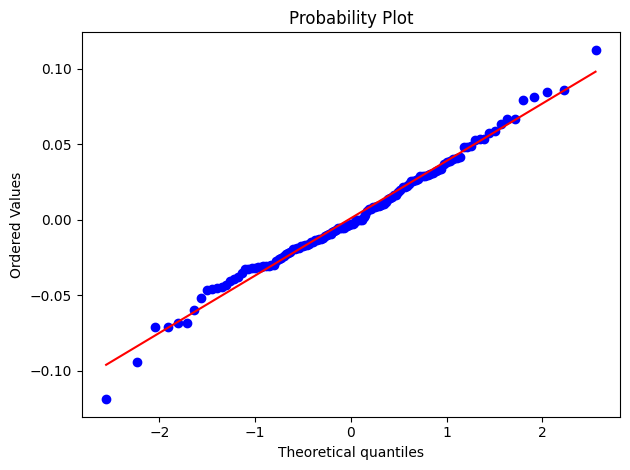

In [13]:
import matplotlib.pyplot as plt
from scipy import stats

fig, ax = plt.subplots()
stats.probplot(residuals, dist='norm', plot=ax);

#### Test

In [14]:
from scipy.stats import jarque_bera
jarque_bera(residuals)

SignificanceResult(statistic=np.float64(1.7634602138073074), pvalue=np.float64(0.41406591332331566))

### Homoscedasticity

#### Plot

In [15]:
residuals.plot()

#### Test

In [16]:
from statsmodels.stats.diagnostic import het_arch
het_arch(residuals)

(np.float64(13.666865388162359),
 np.float64(0.18873629093570043),
 1.400644077091974,
 0.18935371962019082)